# Prep

Load data

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("MJMusicDataset.csv")

# Quick check
print(df.shape)
print(df.head())


(926, 72)
                              name dastgah instrument  zero_corssing  \
0         ney-mahoor-ebrahimi .mp3     D_2        I_4          65545   
1  Mohammad_Shojaei_nei_Mahoor.mp3     D_2        I_4          59788   
2      Arash_Samimi_nei_Mahoor.mp3     D_2        I_4          85072   
3          19 sarebaang mahoor.mp3     D_2        I_4          89980   
4                     Amjadian.mp3     D_2        I_4          58134   

   spectral_centroid_mean  spectral_centroid_var  spectral_rolloff_mean  \
0             1938.040517            303472.4474            2815.166310   
1             1956.981873            774951.2677            2971.032035   
2             2735.525193            575671.7929            4268.615855   
3             2629.389833            406198.9319            4071.233715   
4             1659.262559            332341.1003            2789.041468   

   spectral_rolloff_var  chroma_1_mean  chroma_2_mean  ...  mfcc_11_var  \
0          1.754412e+06       0

Summery of data

In [2]:
# Abstract summary of dataset
summary = {
    "shape": df.shape,
    "columns": list(df.columns),
    "dtypes": df.dtypes.value_counts().to_dict(),
    "missing_total": int(df.isnull().sum().sum()),
    "missing_by_col": df.isnull().sum()[df.isnull().sum() > 0].to_dict(),
    "numeric_cols": df.select_dtypes(include='number').shape[1],
    "categorical_cols": df.select_dtypes(exclude='number').shape[1],
    "sample": df.sample(3).to_dict(orient="records")
}

import pprint
pprint.pprint(summary, width=120)


{'categorical_cols': 3,
 'columns': ['name',
             'dastgah',
             'instrument',
             'zero_corssing',
             'spectral_centroid_mean',
             'spectral_centroid_var',
             'spectral_rolloff_mean',
             'spectral_rolloff_var',
             'chroma_1_mean',
             'chroma_2_mean',
             'chroma_3_mean',
             'chroma_4_mean',
             'chroma_5_mean',
             'chroma_6_mean',
             'chroma_7_mean',
             'chroma_8_mean',
             'chroma_9_mean',
             'chroma_10_mean',
             'chroma_11_mean',
             'chroma_12_mean',
             'chroma_1_var',
             'chroma_2_var',
             'chroma_3_var',
             'chroma_4_var',
             'chroma_5_var',
             'chroma_6_var',
             'chroma_7_var',
             'chroma_8_var',
             'chroma_9_var',
             'chroma_10_var',
             'chroma_11_var',
             'chroma_12_var',
        

In [3]:
df.head()

,name,dastgah,instrument,zero_corssing,spectral_centroid_mean,spectral_centroid_var,spectral_rolloff_mean,spectral_rolloff_var,chroma_1_mean,chroma_2_mean,...,mfcc_11_var,mfcc_12_var,mfcc_13_var,mfcc_14_var,mfcc_15_var,mfcc_16_var,mfcc_17_var,mfcc_18_var,mfcc_19_var,mfcc_20_var
0,ney-mahoor-ebrahimi .mp3,D_2,I_4,65545,1938.040517,303472.4474,2815.166310,1.754412e+06,0.515210,0.158007,...,482.619965,274.530334,257.260315,200.793167,177.008484,89.304535,49.159683,83.412254,154.657501,417.060425
1,Mohammad_Shojaei_nei_Mahoor.mp3,D_2,I_4,59788,1956.981873,774951.2677,2971.032035,2.082504e+06,0.209722,0.335278,...,435.338196,289.941559,337.219269,266.507416,256.131317,153.390289,90.073257,120.354729,206.031006,267.015015
2,Arash_Samimi_nei_Mahoor.mp3,D_2,I_4,85072,2735.525193,575671.7929,4268.615855,2.663909e+06,0.105867,0.108526,...,299.526794,226.705948,163.451355,140.664673,104.658630,72.048088,53.397228,83.085548,190.668487,331.626526
3,19 sarebaang mahoor.mp3,D_2,I_4,89980,2629.389833,406198.9319,4071.233715,1.005496e+06,0.153988,0.098157,...,305.978638,154.510696,281.793976,348.872650,156.062454,85.470512,45.904568,120.363800,370.077820,306.180878
4,Amjadian.mp3,D_2,I_4,58134,1659.262559,332341.1003,2789.041468,8.496746e+05,0.077795,0.036009,...,81.764854,106.146141,103.081779,85.252548,90.831291,150.201111,332.417633,299.858795,177.197845,186.112488


# Analysis

distribution of Dastgah

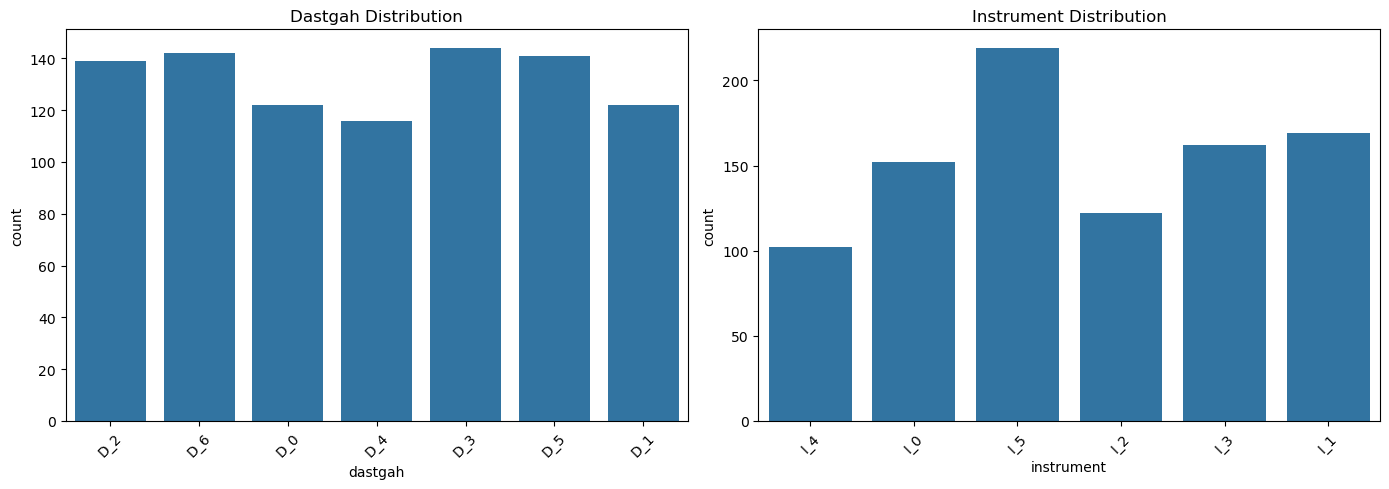

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- categorical balance ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x="dastgah", data=df, ax=axes[0])
axes[0].set_title("Dastgah Distribution")
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(x="instrument", data=df, ax=axes[1])
axes[1].set_title("Instrument Distribution")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



In [5]:
import pandas as pd
import numpy as np

def generate_extra_features(df: pd.DataFrame) -> pd.DataFrame:
    df_new = df.copy()

    # ---- MFCC features ----
    mfcc_means = [c for c in df.columns if "mfcc_" in c and "_mean" in c]
    mfcc_vars = [c for c in df.columns if "mfcc_" in c and "_var" in c]

    # Approximate deltas: diff between adjacent MFCCs
    for i in range(len(mfcc_means) - 1):
        df_new[f"mfcc_delta_mean_{i+1}_{i+2}"] = df[mfcc_means[i+1]] - df[mfcc_means[i]]
        df_new[f"mfcc_delta_var_{i+1}_{i+2}"] = df[mfcc_vars[i+1]] - df[mfcc_vars[i]]

    # MFCC energy: sum of absolute means
    df_new["mfcc_energy"] = df[mfcc_means].abs().sum(axis=1)

    # ---- Chroma features ----
    chroma_means = [c for c in df.columns if "chroma_" in c and "_mean" in c]

    # Chroma entropy (spread of pitch distribution)
    chroma_vals = df[chroma_means].values
    chroma_probs = chroma_vals / (chroma_vals.sum(axis=1, keepdims=True) + 1e-9)
    chroma_entropy = -np.sum(chroma_probs * np.log(chroma_probs + 1e-9), axis=1)
    df_new["chroma_entropy"] = chroma_entropy

    # ---- Spectral features ----
    if "spectral_centroid_mean" in df.columns and "spectral_rolloff_mean" in df.columns:
        # Spectral spread proxy = rolloff - centroid
        df_new["spectral_spread"] = df["spectral_rolloff_mean"] - df["spectral_centroid_mean"]

    if "spectral_centroid_var" in df.columns:
        # Spectral skewness proxy = sqrt(var)/mean
        df_new["spectral_skewness"] = np.sqrt(df["spectral_centroid_var"]) / (df["spectral_centroid_mean"] + 1e-9)

    return df_new


In [6]:
# Generate features
df_expanded = generate_extra_features(df)

print("Original shape:", df.shape)
print("Expanded shape:", df_expanded.shape)
df_expanded.head()


Original shape: (926, 72)
Expanded shape: (926, 114)


,name,dastgah,instrument,zero_corssing,spectral_centroid_mean,spectral_centroid_var,spectral_rolloff_mean,spectral_rolloff_var,chroma_1_mean,chroma_2_mean,...,mfcc_delta_mean_17_18,mfcc_delta_var_17_18,mfcc_delta_mean_18_19,mfcc_delta_var_18_19,mfcc_delta_mean_19_20,mfcc_delta_var_19_20,mfcc_energy,chroma_entropy,spectral_spread,spectral_skewness
0,ney-mahoor-ebrahimi .mp3,D_2,I_4,65545,1938.040517,303472.4474,2815.166310,1.754412e+06,0.515210,0.158007,...,1.927956,34.252571,1.635947,71.245247,16.910147,262.402924,627.413538,2.308916,877.125793,0.284248
1,Mohammad_Shojaei_nei_Mahoor.mp3,D_2,I_4,59788,1956.981873,774951.2677,2971.032035,2.082504e+06,0.209722,0.335278,...,0.876564,30.281471,0.487823,85.676277,8.431968,60.984009,608.988596,2.415876,1014.050162,0.449832
2,Arash_Samimi_nei_Mahoor.mp3,D_2,I_4,85072,2735.525193,575671.7929,4268.615855,2.663909e+06,0.105867,0.108526,...,3.240563,29.688320,-10.800689,107.582939,11.354733,140.958038,519.966228,2.235210,1533.090662,0.277362
3,19 sarebaang mahoor.mp3,D_2,I_4,89980,2629.389833,406198.9319,4071.233715,1.005496e+06,0.153988,0.098157,...,14.230557,74.459232,-17.127592,249.714020,-4.759473,-63.896942,597.490624,2.268764,1441.843882,0.242390
4,Amjadian.mp3,D_2,I_4,58134,1659.262559,332341.1003,2789.041468,8.496746e+05,0.077795,0.036009,...,13.385057,-32.558838,9.709909,-122.660950,17.169054,8.914642,798.083883,2.036863,1129.778909,0.347438


In [7]:
df = df_expanded

Train test split

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Features
X = df.drop(columns=["name", "instrument", "dastgah"])

# Labels as numbers
le = LabelEncoder()
y = le.fit_transform(df["dastgah"])   # e.g. D_0 → 0, D_1 → 1, ...

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print("Classes:", le.classes_)


(740, 111) (186, 111) (740,) (186,)
Classes: ['D_0' 'D_1' 'D_2' 'D_3' 'D_4' 'D_5' 'D_6']


In [9]:
X.columns

Index(['zero_corssing', 'spectral_centroid_mean', 'spectral_centroid_var',
       'spectral_rolloff_mean', 'spectral_rolloff_var', 'chroma_1_mean',
       'chroma_2_mean', 'chroma_3_mean', 'chroma_4_mean', 'chroma_5_mean',
       ...
       'mfcc_delta_mean_17_18', 'mfcc_delta_var_17_18',
       'mfcc_delta_mean_18_19', 'mfcc_delta_var_18_19',
       'mfcc_delta_mean_19_20', 'mfcc_delta_var_19_20', 'mfcc_energy',
       'chroma_entropy', 'spectral_spread', 'spectral_skewness'],
      dtype='object', length=111)

distribution after train test split

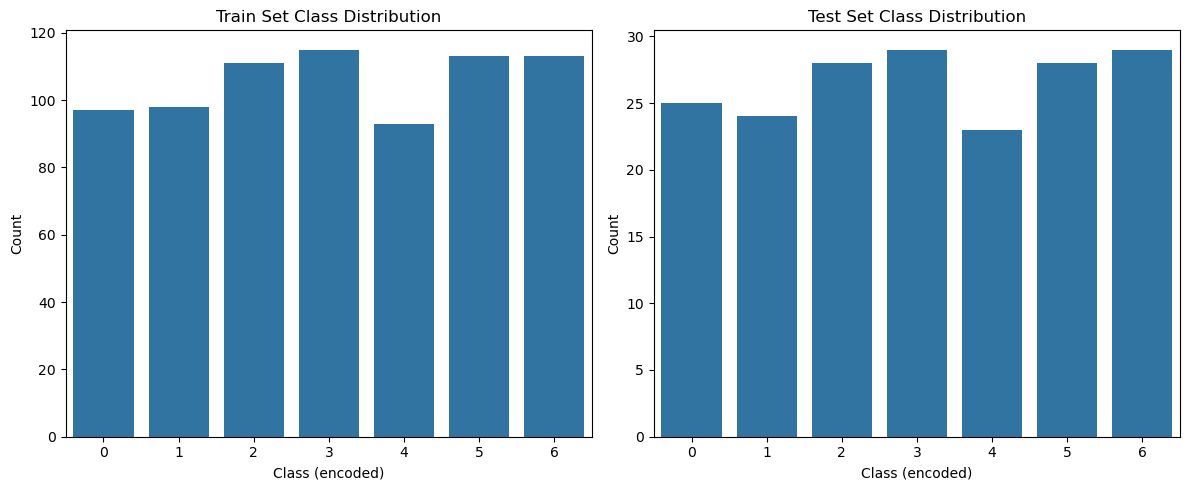

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Bar plots: class balance in train/test ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Train Set Class Distribution")
axes[0].set_xlabel("Class (encoded)")
axes[0].set_ylabel("Count")

sns.countplot(x=y_test, ax=axes[1])
axes[1].set_title("Test Set Class Distribution")
axes[1].set_xlabel("Class (encoded)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()



normalization

In [11]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training data, transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, " Test shape:", X_test_scaled.shape)


Train shape: (740, 111)  Test shape: (186, 111)


In [12]:
from imblearn.over_sampling import RandomOverSampler

# Oversample train set only
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train_scaled, y_train)

print("Before:", dict(zip(*np.unique(y_train, return_counts=True))))
print("After :", dict(zip(*np.unique(y_train_bal, return_counts=True))))


Before: {0: 97, 1: 98, 2: 111, 3: 115, 4: 93, 5: 113, 6: 113}
After : {0: 115, 1: 115, 2: 115, 3: 115, 4: 115, 5: 115, 6: 115}


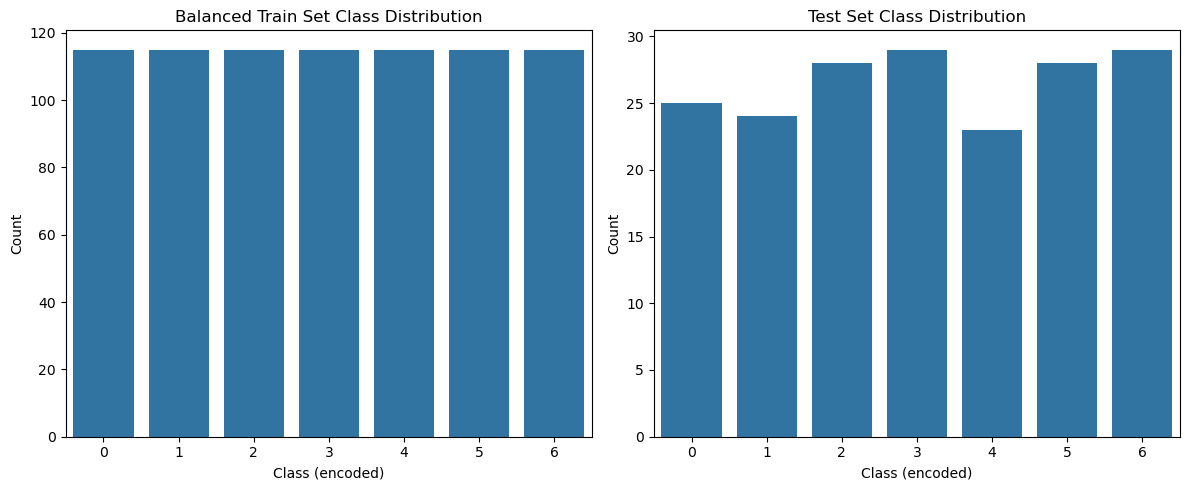

In [13]:
from imblearn.over_sampling import RandomOverSampler

# Oversample train set
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train_scaled, y_train)

# --- Bar plots: balanced vs test ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y_train_bal, ax=axes[0])
axes[0].set_title("Balanced Train Set Class Distribution")
axes[0].set_xlabel("Class (encoded)")
axes[0].set_ylabel("Count")

sns.countplot(x=y_test, ax=axes[1])
axes[1].set_title("Test Set Class Distribution")
axes[1].set_xlabel("Class (encoded)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001965 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 27416
[LightGBM] [Info] Number of data points in the train set: 740, number of used features: 111
[LightGBM] [Info] Start training from score -2.031939
[LightGBM] [Info] Start training from score -2.021683
[LightGBM] [Info] Start training from score -1.897120
[LightGBM] [Info] Start training from score -1.861718
[LightGBM] [Info] Start training from score -2.074051
[LightGBM] [Info] Start training from score -1.879262
[LightGBM] [Info] Start training from score -1.879262
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

/home/alireza-linux/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


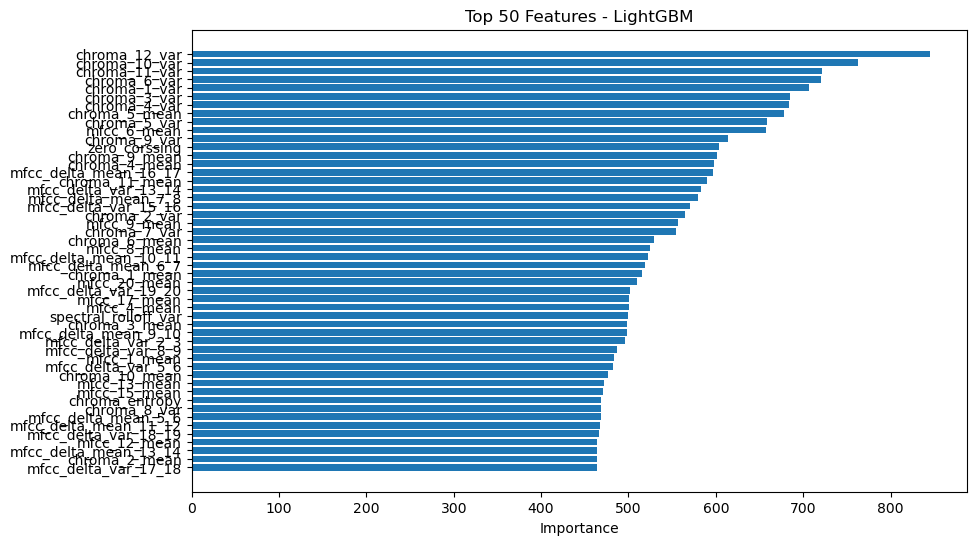

In [14]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# --- Train LightGBM ---
lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

lgbm.fit(X_train_scaled, y_train)

# --- Predictions ---
y_pred = lgbm.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --- Feature importance ---
importances = lgbm.feature_importances_
sorted_idx = importances.argsort()[::-1][:50]  # top 20 features

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), importances[sorted_idx][::-1])
plt.yticks(range(len(sorted_idx)), [X.columns[i] for i in sorted_idx][::-1])
plt.xlabel("Importance")
plt.title("Top 50 Features - LightGBM")
plt.show()


In [15]:
# --- Select top k features ---
k = 50  # change to 20 if you want leaner

# Get top-k feature indices from LightGBM importances
importances = lgbm.feature_importances_
sorted_idx = importances.argsort()[::-1][:k]
top_features = [X.columns[i] for i in sorted_idx]

print("Top features:", top_features)

# Filter both train and test
X_train_top = X_train_scaled[:, sorted_idx]
X_test_top = X_test_scaled[:, sorted_idx]

print("Train shape:", X_train_top.shape, " Test shape:", X_test_top.shape)


Top features: ['chroma_12_var', 'chroma_10_var', 'chroma_11_var', 'chroma_6_var', 'chroma_1_var', 'chroma_3_var', 'chroma_4_var', 'chroma_5_mean', 'chroma_5_var', 'mfcc_6_mean', 'chroma_9_var', 'zero_corssing', 'chroma_9_mean', 'chroma_4_mean', 'mfcc_delta_mean_16_17', 'chroma_11_mean', 'mfcc_delta_var_13_14', 'mfcc_delta_mean_7_8', 'mfcc_delta_var_15_16', 'chroma_2_var', 'mfcc_9_mean', 'chroma_7_var', 'chroma_6_mean', 'mfcc_8_mean', 'mfcc_delta_mean_10_11', 'mfcc_delta_mean_6_7', 'chroma_1_mean', 'mfcc_20_mean', 'mfcc_delta_var_19_20', 'mfcc_17_mean', 'mfcc_4_mean', 'spectral_rolloff_var', 'chroma_3_mean', 'mfcc_delta_mean_9_10', 'mfcc_delta_var_2_3', 'mfcc_delta_var_8_9', 'mfcc_1_mean', 'mfcc_delta_var_5_6', 'chroma_10_mean', 'mfcc_13_mean', 'mfcc_15_mean', 'chroma_entropy', 'chroma_8_var', 'mfcc_delta_mean_5_6', 'mfcc_delta_mean_11_12', 'mfcc_delta_var_18_19', 'mfcc_12_mean', 'mfcc_delta_mean_13_14', 'chroma_2_mean', 'mfcc_delta_var_17_18']
Train shape: (740, 50)  Test shape: (186, 

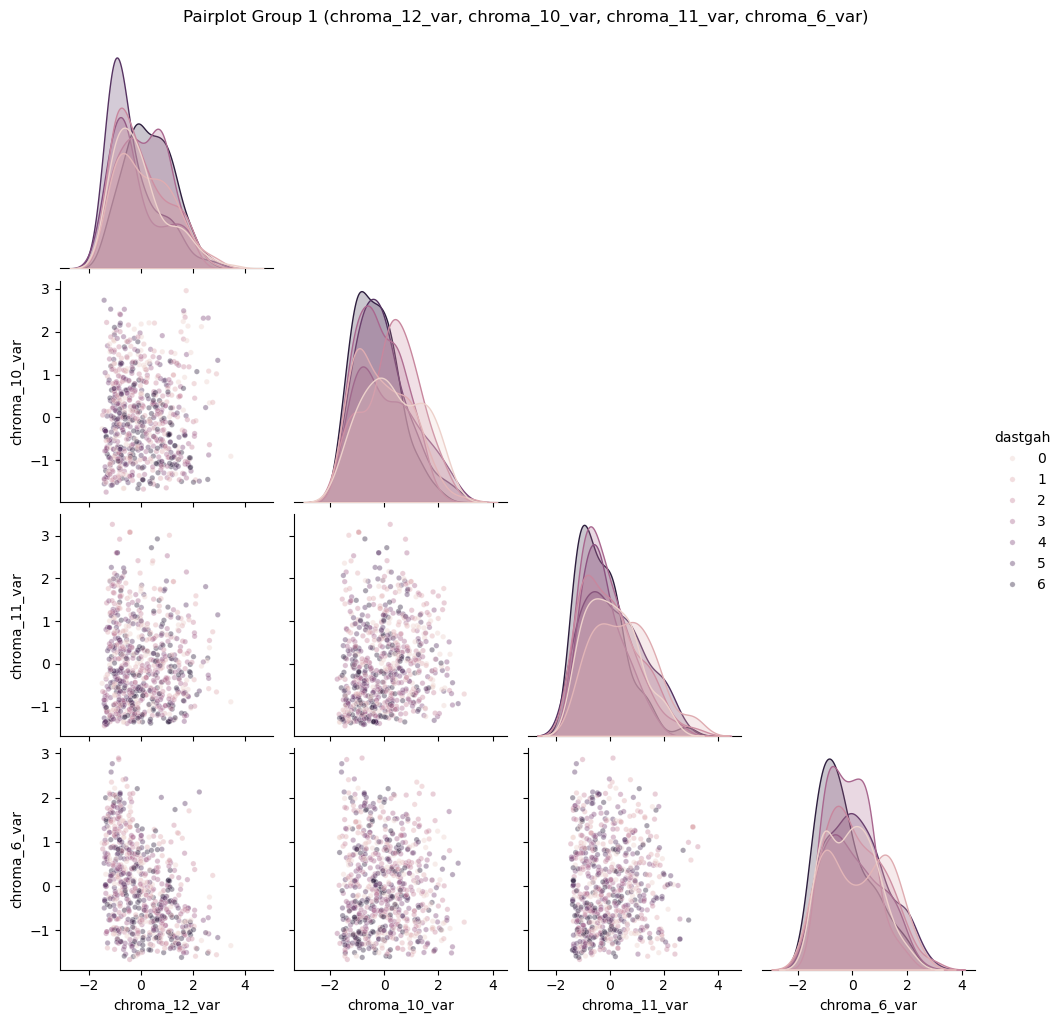

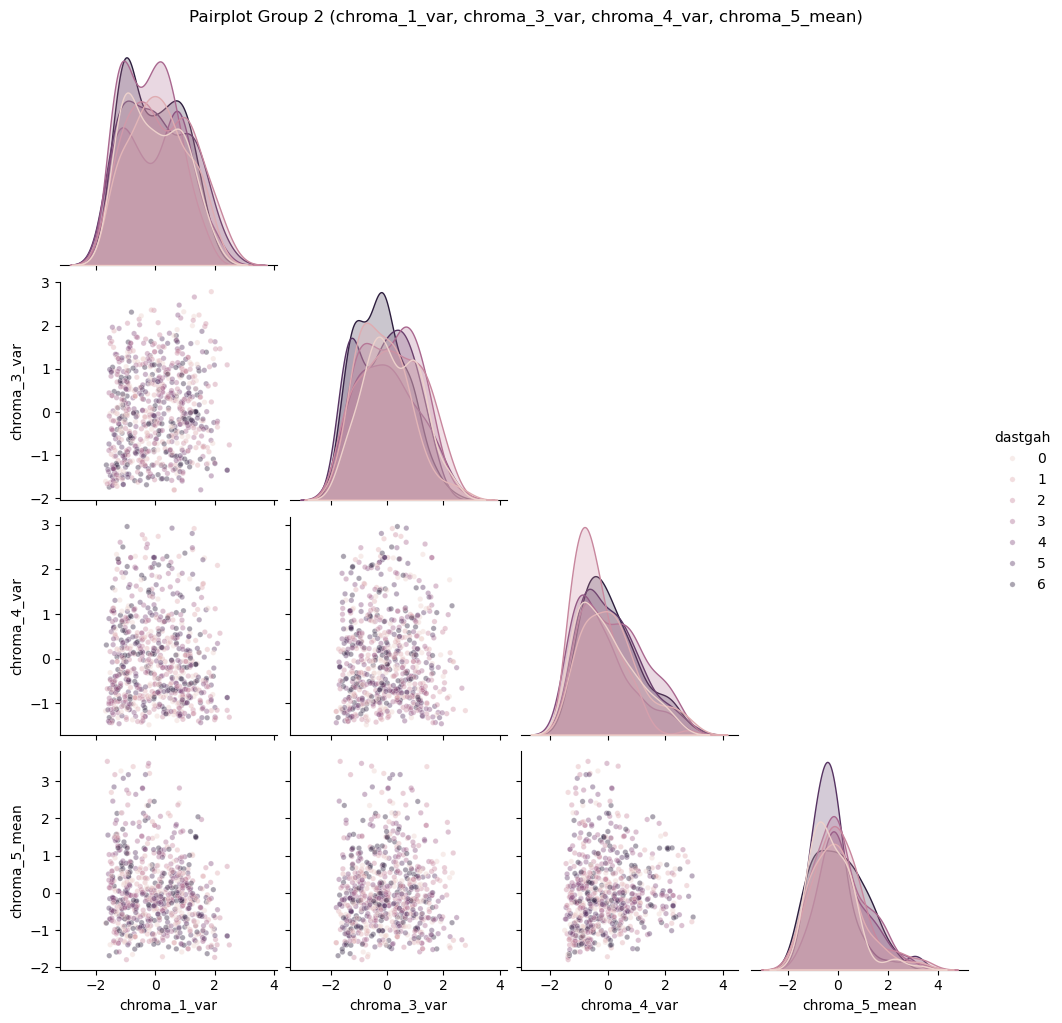

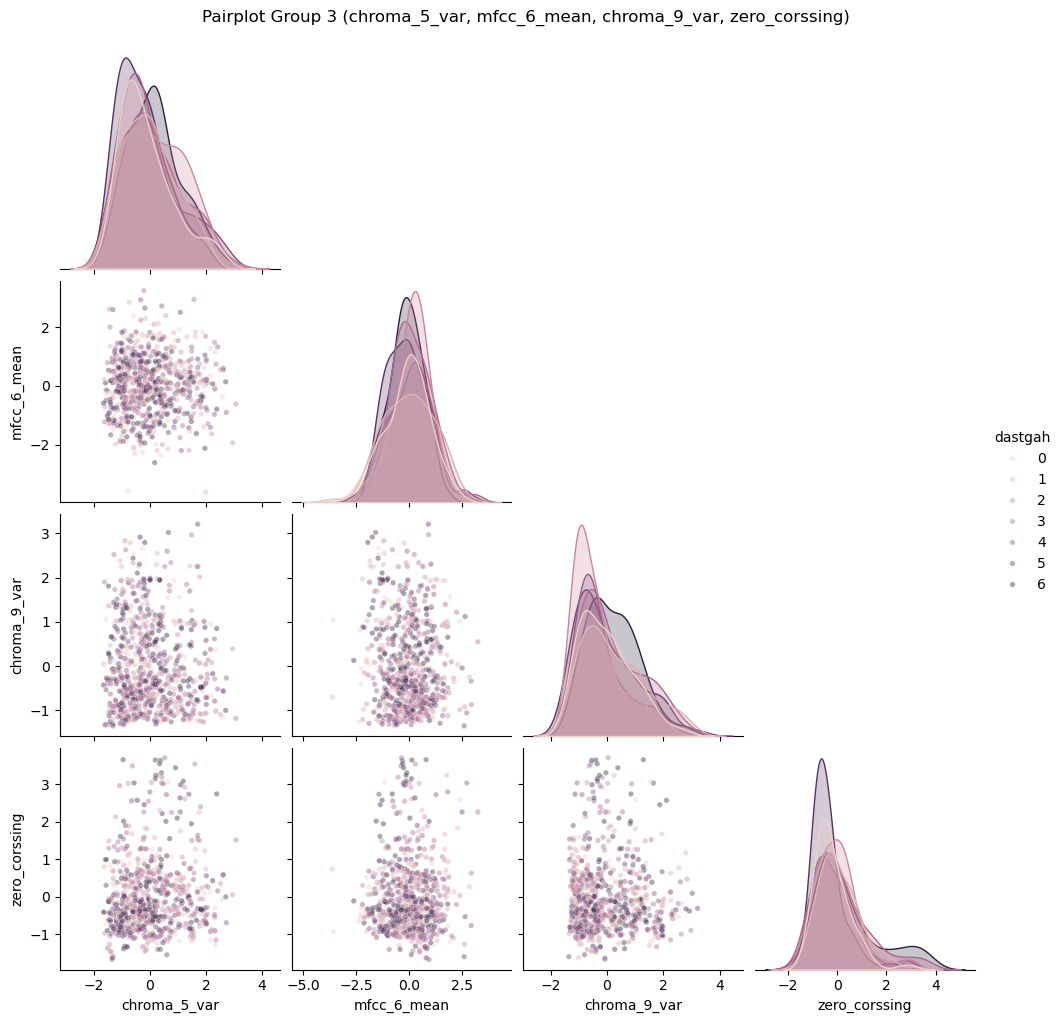

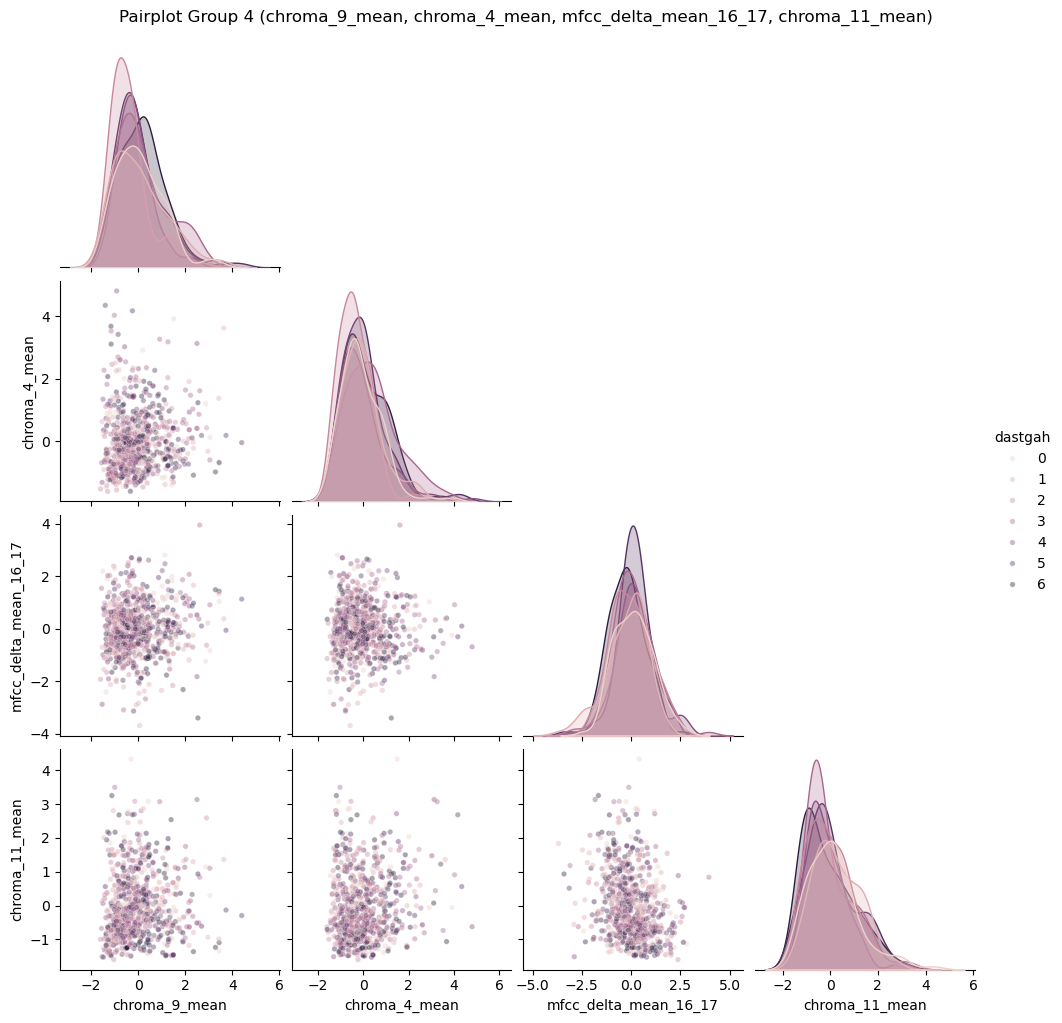

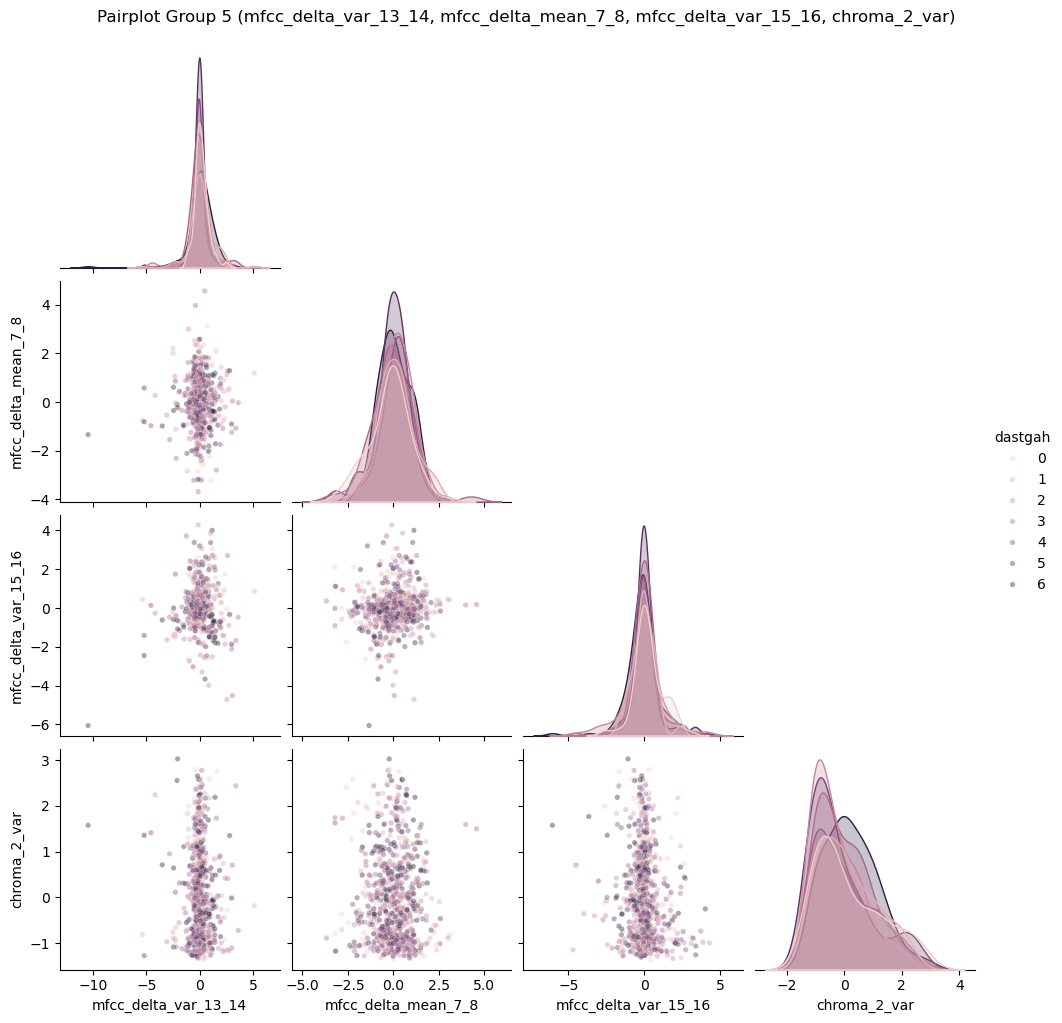

In [16]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Top 20 features
k = 50
sorted_idx = importances.argsort()[::-1][:k]
top50_features = [X.columns[i] for i in sorted_idx]

# Rebuild scaled DataFrame for train set
X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_train_top50 = X_train_df[top50_features].copy()
X_train_top50["dastgah"] = y_train  # labels for coloring

# Split into 5 groups of 4 features
groups = [top50_features[i:i+4] for i in range(0, 20, 4)]

for i, g in enumerate(groups, 1):
    sns.pairplot(
        X_train_top50[g + ["dastgah"]],
        hue="dastgah",
        diag_kind="kde",
        corner=True,
        plot_kws={'alpha':0.4, 's':15}
    )
    plt.suptitle(f"Pairplot Group {i} ({', '.join(g)})", y=1.02)
    plt.show()


# Model Training

linear svm

In [17]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Select top-20 features from LightGBM ranking
k = 50
sorted_idx = importances.argsort()[::-1][:k]

X_train_top50 = X_train_scaled[:, sorted_idx]
X_test_top50 = X_test_scaled[:, sorted_idx]

# Train linear SVM
svm = SVC(kernel="linear", random_state=42)
svm.fit(X_train_top50, y_train)

# Evaluate
y_pred = svm.predict(X_test_top50)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.34946236559139787

Classification Report:
               precision    recall  f1-score   support

           0       0.30      0.36      0.33        25
           1       0.31      0.33      0.32        24
           2       0.36      0.29      0.32        28
           3       0.33      0.31      0.32        29
           4       0.31      0.22      0.26        23
           5       0.41      0.57      0.48        28
           6       0.38      0.34      0.36        29

    accuracy                           0.35       186
   macro avg       0.34      0.35      0.34       186
weighted avg       0.35      0.35      0.34       186



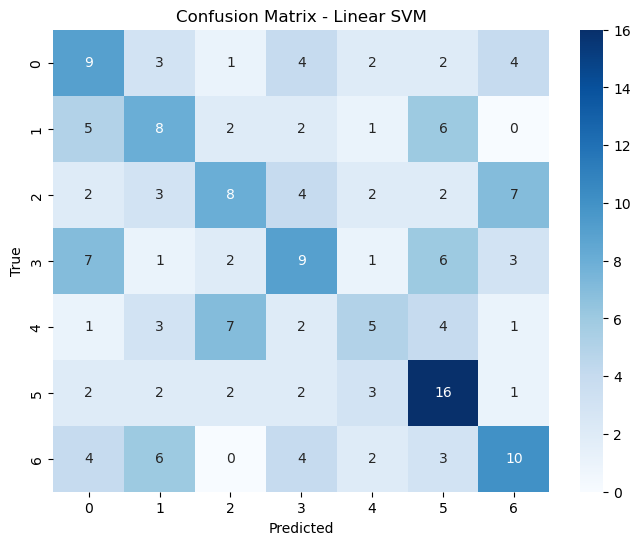

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Linear SVM")
plt.show()



Kernel: linear
Accuracy: 0.34946236559139787
              precision    recall  f1-score   support

           0       0.30      0.36      0.33        25
           1       0.31      0.33      0.32        24
           2       0.36      0.29      0.32        28
           3       0.33      0.31      0.32        29
           4       0.31      0.22      0.26        23
           5       0.41      0.57      0.48        28
           6       0.38      0.34      0.36        29

    accuracy                           0.35       186
   macro avg       0.34      0.35      0.34       186
weighted avg       0.35      0.35      0.34       186


Kernel: rbf
Accuracy: 0.41935483870967744
              precision    recall  f1-score   support

           0       0.14      0.12      0.13        25
           1       0.43      0.42      0.43        24
           2       0.44      0.39      0.42        28
           3       0.46      0.55      0.50        29
           4       0.40      0.17      0.24

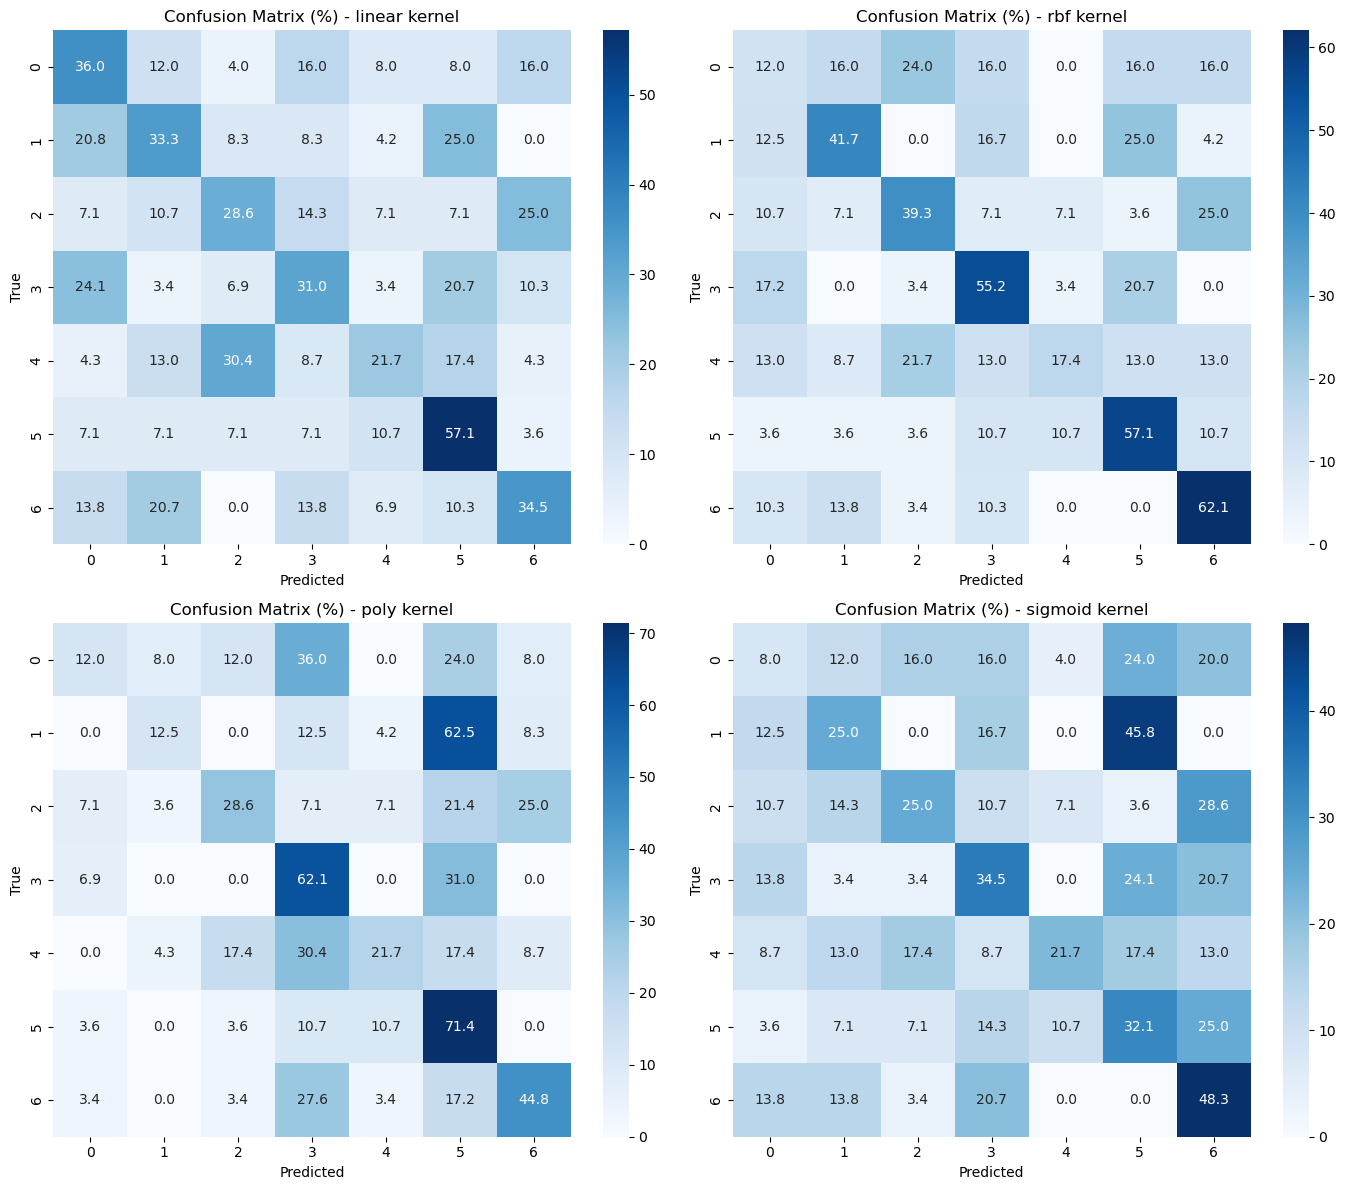

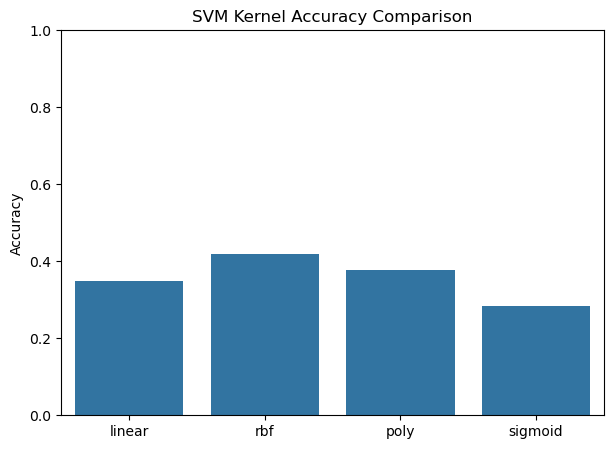

In [20]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

kernels = ["linear", "rbf", "poly", "sigmoid"]
results = {}
cms = {}

# Train and evaluate for each kernel
for k in kernels:
    svm = SVC(kernel=k, C=1.0, gamma="scale", random_state=42)
    svm.fit(X_train_top50, y_train)
    y_pred_k = svm.predict(X_test_top50)
    
    acc = accuracy_score(y_test, y_pred_k)
    results[k] = acc
    
    cm = confusion_matrix(y_test, y_pred_k, labels=np.unique(y))
    cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100
    cms[k] = cm_percent
    
    print(f"\nKernel: {k}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred_k))

# --- Plot confusion matrices (percent) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for i, k in enumerate(kernels):
    sns.heatmap(cms[k], annot=True, fmt=".1f", cmap="Blues",
                xticklabels=np.unique(y), yticklabels=np.unique(y), ax=axes[i])
    axes[i].set_title(f"Confusion Matrix (%) - {k} kernel")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("True")

plt.tight_layout()
plt.show()

# --- Plot comparison of accuracies ---
plt.figure(figsize=(7,5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title("SVM Kernel Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()


## Grid search

In [22]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1],
    "kernel": ["rbf"]
}

# SVM with probability
svm = SVC(probability=True, random_state=42)

# Grid search
grid = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,               # 5-fold cross-validation
    scoring="accuracy", # optimize accuracy
    n_jobs=-1,          # parallel
    verbose=2
)

grid.fit(X_train_top50, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

# Evaluate on test set
best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test_top50)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.2s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.2s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.2s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.2s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.2s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.2s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.2s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.2s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.2s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.2s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.2s
[CV] END ......................C=0.1, gamma=0.01

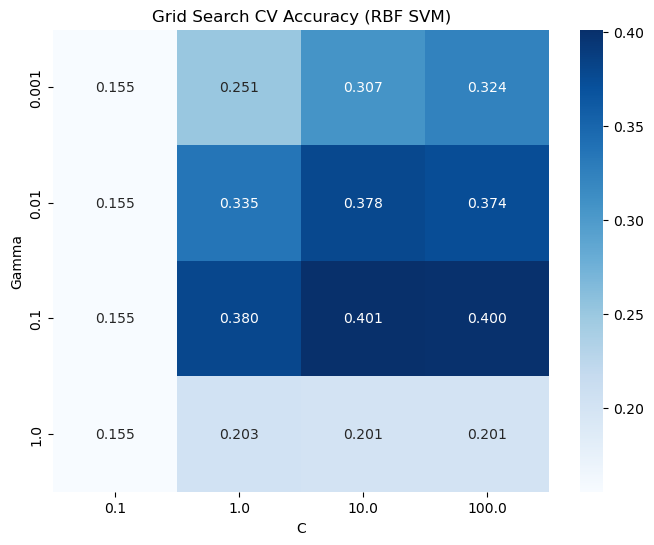

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extract results into DataFrame
results_df = pd.DataFrame(grid.cv_results_)

# Pivot to matrix form for heatmap
heatmap_data = results_df.pivot(
    index="param_gamma",
    columns="param_C",
    values="mean_test_score"
)

plt.figure(figsize=(8,6))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="Blues")
plt.title("Grid Search CV Accuracy (RBF SVM)")
plt.ylabel("Gamma")
plt.xlabel("C")
plt.show()


Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END ....................C=0.1, gamma=0.0001, kernel=rbf; total time=   0.2s
[CV] END ....................C=0.1, gamma=0.0001, kernel=rbf; total time=   0.2s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.2s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.2s
[CV] END ....................C=0.1, gamma=0.0001, kernel=rbf; total time=   0.2s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.2s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.2s
[CV] END ....................C=0.1, gamma=0.0001, kernel=rbf; total time=   0.2s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.2s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.2s
[CV] END ....................C=0.1, gamma=0.0001, kernel=rbf; total time=   0.2s
[CV] END ......................C=0.1, gamma=0.0

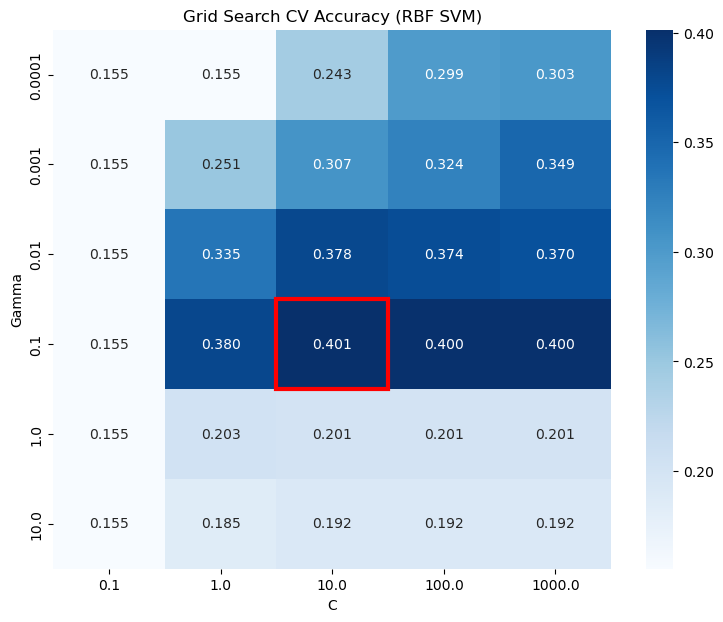

In [24]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Expanded parameter grid
param_grid = {
    "C": [0.1, 1, 10, 100, 1000],
    "gamma": [0.0001, 0.001, 0.01, 0.1, 1, 10],
    "kernel": ["rbf"]
}

# Grid search
svm = SVC(probability=True, random_state=42)
grid = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)
grid.fit(X_train_top50, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

# Heatmap of results
results_df = pd.DataFrame(grid.cv_results_)
heatmap_data = results_df.pivot(
    index="param_gamma",
    columns="param_C",
    values="mean_test_score"
)

plt.figure(figsize=(9,7))
ax = sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="Blues")

# Mark the best params
best_gamma = grid.best_params_["gamma"]
best_C = grid.best_params_["C"]
ax.add_patch(plt.Rectangle(
    (list(heatmap_data.columns).index(best_C), list(heatmap_data.index).index(best_gamma)),
    1, 1, fill=False, edgecolor="red", lw=3
))

plt.title("Grid Search CV Accuracy (RBF SVM)")
plt.ylabel("Gamma")
plt.xlabel("C")
plt.show()


Test accuracy: 0.5053763440860215

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.16      0.27        25
           1       0.90      0.38      0.53        24
           2       0.32      0.64      0.43        28
           3       0.43      0.79      0.55        29
           4       1.00      0.22      0.36        23
           5       0.50      0.46      0.48        28
           6       0.73      0.76      0.75        29

    accuracy                           0.51       186
   macro avg       0.67      0.49      0.48       186
weighted avg       0.65      0.51      0.49       186



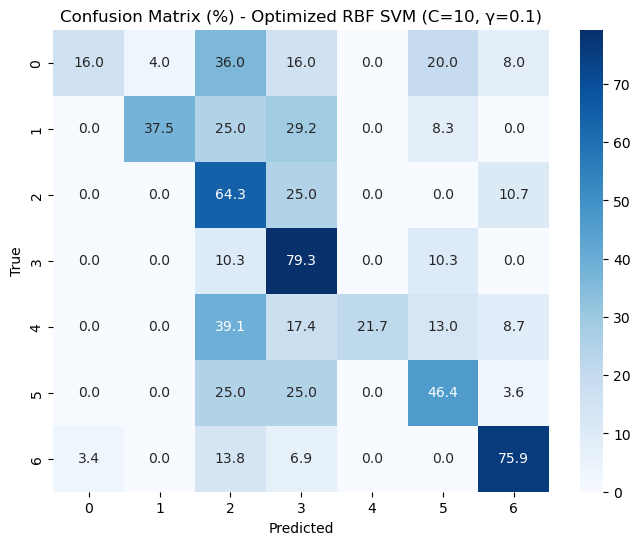

In [25]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Retrain with best params
best_svm = SVC(
    kernel="rbf",
    C=10,
    gamma=0.1,
    probability=True,
    random_state=42
)
best_svm.fit(X_train_top50, y_train)

# Evaluate on test set
y_pred = best_svm.predict(X_test_top50)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix (percent)
cm = confusion_matrix(y_test, y_pred, labels=np.unique(y))
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(8,6))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (%) - Optimized RBF SVM (C=10, γ=0.1)")
plt.show()


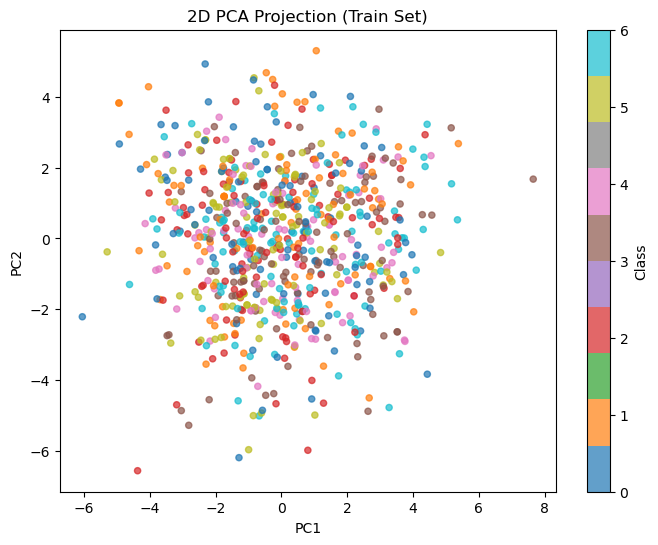

In [26]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import plotly.express as px

# ---------- PCA 2D ----------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_top50)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, cmap="tab10", alpha=0.7, s=20)  # smaller points
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection (Train Set)")
plt.colorbar(label="Class")
plt.show()

# ---------- LDA 3D ----------
lda = LDA(n_components=3)
X_lda = lda.fit_transform(X_train_top50, y_train)

fig = px.scatter_3d(
    x=X_lda[:,0],
    y=X_lda[:,1],
    z=X_lda[:,2],
    color=y_train.astype(str),
    title="3D LDA Projection (Train Set)",
    labels={"color": "Class"},
    size_max=1  # shrink bubble size
)
fig.show()


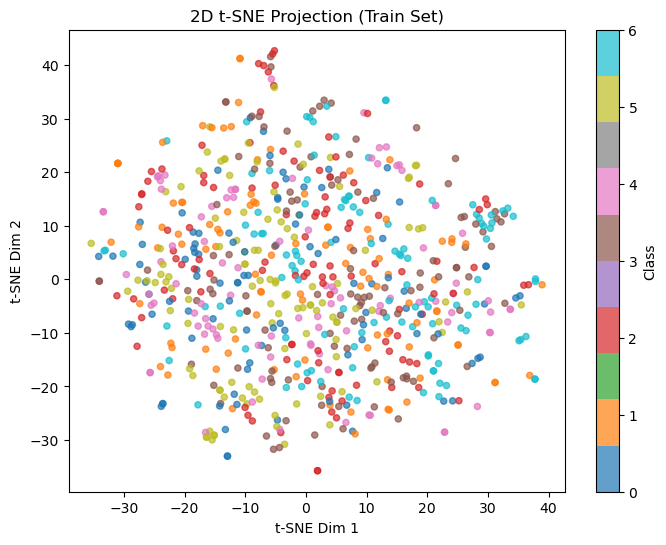

In [27]:
from sklearn.manifold import TSNE

# ---------- t-SNE 2D ----------
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_train_top50)

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_train, cmap="tab10", alpha=0.7, s=20)
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")
plt.title("2D t-SNE Projection (Train Set)")
plt.colorbar(label="Class")
plt.show()


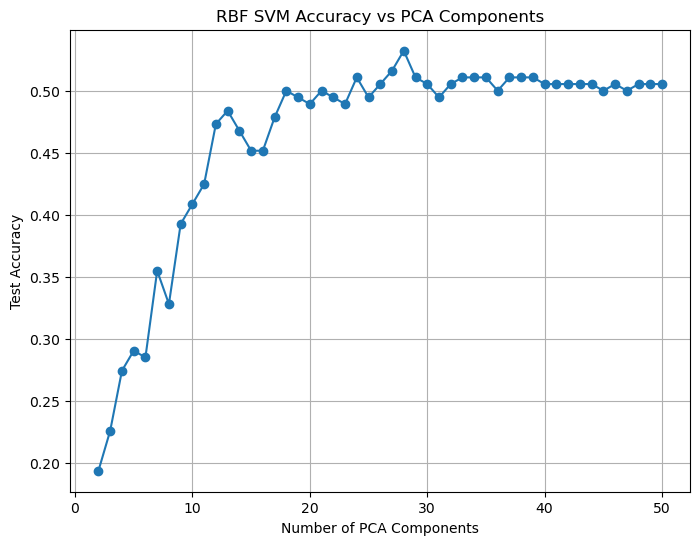

In [28]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

accuracies = []
components = list(range(2, X_train_top50.shape[1]+1))  # from 2 up to 50

for n in components:
    # PCA reduction
    pca = PCA(n_components=n, random_state=42)
    X_train_pca = pca.fit_transform(X_train_top50)
    X_test_pca = pca.transform(X_test_top50)
    
    # RBF SVM with optimized params
    svm = SVC(
        kernel="rbf",
        C=10,
        gamma=0.1,
        probability=True,
        random_state=42
    )
    svm.fit(X_train_pca, y_train)
    y_pred = svm.predict(X_test_pca)
    
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

# Plot results
plt.figure(figsize=(8,6))
plt.plot(components, accuracies, marker="o")
plt.xlabel("Number of PCA Components")
plt.ylabel("Test Accuracy")
plt.title("RBF SVM Accuracy vs PCA Components")
plt.grid(True)
plt.show()


Test accuracy: 0.532258064516129

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.20      0.30        25
           1       0.86      0.50      0.63        24
           2       0.37      0.64      0.47        28
           3       0.49      0.72      0.58        29
           4       0.78      0.30      0.44        23
           5       0.48      0.50      0.49        28
           6       0.65      0.76      0.70        29

    accuracy                           0.53       186
   macro avg       0.61      0.52      0.52       186
weighted avg       0.60      0.53      0.52       186



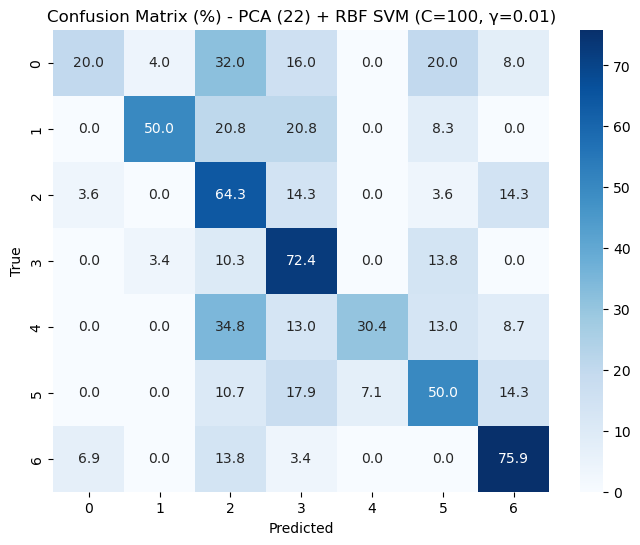

In [30]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- PCA (22 components) ---
pca = PCA(n_components=28, random_state=42)
X_train_pca = pca.fit_transform(X_train_top50)   # use top 50 features before PCA
X_test_pca = pca.transform(X_test_top50)

# --- Retrain with optimized RBF SVM ---
best_svm = SVC(
    kernel="rbf",
    C=10,
    gamma=0.1,
    probability=True,
    random_state=42
)
best_svm.fit(X_train_pca, y_train)

# --- Evaluate on test set ---
y_pred = best_svm.predict(X_test_pca)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --- Confusion matrix (percent) ---
cm = confusion_matrix(y_test, y_pred, labels=np.unique(y))
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(8,6))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (%) - PCA (22) + RBF SVM (C=100, γ=0.01)")
plt.show()


Epoch 1/400
11/11 - 3s - 310ms/step - loss: 1.6644 - val_loss: 1.4804
Epoch 2/400
11/11 - 0s - 6ms/step - loss: 1.6234 - val_loss: 1.4539
Epoch 3/400
11/11 - 0s - 6ms/step - loss: 1.5994 - val_loss: 1.4278
Epoch 4/400
11/11 - 0s - 5ms/step - loss: 1.5688 - val_loss: 1.3960
Epoch 5/400
11/11 - 0s - 6ms/step - loss: 1.5243 - val_loss: 1.3529
Epoch 6/400
11/11 - 0s - 6ms/step - loss: 1.4695 - val_loss: 1.2976
Epoch 7/400
11/11 - 0s - 6ms/step - loss: 1.4102 - val_loss: 1.2424
Epoch 8/400
11/11 - 0s - 6ms/step - loss: 1.3575 - val_loss: 1.1912
Epoch 9/400
11/11 - 0s - 6ms/step - loss: 1.3007 - val_loss: 1.1413
Epoch 10/400
11/11 - 0s - 6ms/step - loss: 1.2532 - val_loss: 1.1003
Epoch 11/400
11/11 - 0s - 6ms/step - loss: 1.2112 - val_loss: 1.0672
Epoch 12/400
11/11 - 0s - 6ms/step - loss: 1.1804 - val_loss: 1.0412
Epoch 13/400
11/11 - 0s - 6ms/step - loss: 1.1472 - val_loss: 1.0156
Epoch 14/400
11/11 - 0s - 6ms/step - loss: 1.1220 - val_loss: 0.9966
Epoch 15/400
11/11 - 0s - 6ms/step - loss

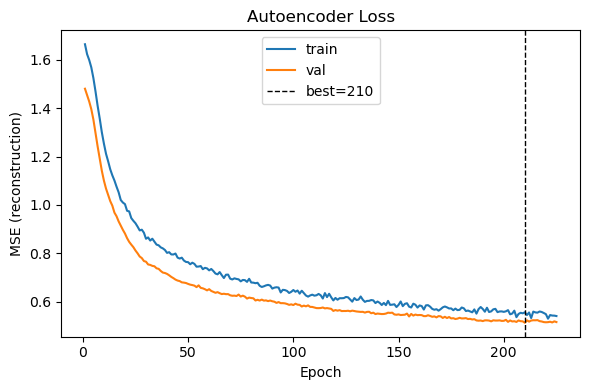

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
(740, 12) (186, 12)


In [35]:
# --- Autoencoder: build, train, extract features ---
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

def build_autoencoder(input_dim, latent_dim=12, hidden=(64, 32), dropout=0.1, lr=1e-3):
    inp = keras.Input(shape=(input_dim,), name="ae_input")
    x = layers.BatchNormalization()(inp)
    for u in hidden:
        x = layers.Dense(u, activation="relu")(x)
        if dropout: x = layers.Dropout(dropout)(x)
    latent = layers.Dense(latent_dim, activation=None, name="latent")(x)  # <-- feature extractor

    x = layers.Dense(hidden[-1], activation="relu")(latent)
    for u in reversed(hidden[:-1]):
        x = layers.Dense(u, activation="relu")(x)
    out = layers.Dense(input_dim, activation=None, name="reconstruction")(x)

    ae = keras.Model(inp, out, name="autoencoder")
    ae.compile(optimizer=keras.optimizers.Adam(lr), loss="mse")
    enc = keras.Model(inp, latent, name="encoder")
    return ae, enc

def train_autoencoder(ae, X_train, val_split=0.1, epochs=200, batch_size=64, patience=15):
    X_tr, X_val = train_test_split(X_train, test_size=val_split, random_state=42)
    cb = [keras.callbacks.EarlyStopping(patience=patience, restore_best_weights=True)]
    hist = ae.fit(X_tr, X_tr,
                  validation_data=(X_val, X_val),
                  epochs=epochs,
                  batch_size=batch_size,
                  verbose=2,
                  callbacks=cb)
    return hist

# ---- train ----
input_dim = X_train_pca.shape[1]     # e.g., 22
ae, encoder = build_autoencoder(input_dim, latent_dim=12, hidden=(64,32), dropout=0.1, lr=1e-3)
hist = train_autoencoder(ae, X_train_pca, val_split=0.1, epochs=400, batch_size=64, patience=15)

# ---- loss plot (uses actual epochs run) ----
epochs_ran = np.arange(1, len(hist.history["loss"]) + 1)
best_epoch = int(np.argmin(hist.history["val_loss"]) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs_ran, hist.history["loss"], label="train")
plt.plot(epochs_ran, hist.history["val_loss"], label="val")
plt.axvline(best_epoch, ls="--", lw=1, color="k", label=f"best={best_epoch}")
plt.xlabel("Epoch"); plt.ylabel("MSE (reconstruction)")
plt.title("Autoencoder Loss")
plt.legend(); plt.tight_layout(); plt.show()

# If you want the x-axis fixed to 400 regardless of early stopping:
# plt.xlim(1, 400)


# ---- extracted features (use these for classifiers) ----
Z_train = encoder.predict(X_train_pca)  # shape: (n_train, latent_dim)
Z_test  = encoder.predict(X_test_pca)   # shape: (n_test,  latent_dim)
print(Z_train.shape, Z_test.shape)


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_input (InputLayer)           │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28)             │           112 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 12)             │           396 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 28)             │         1,820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,266 (102.61 KB)

 Trainable params: 8,736 (34.12 KB)

 Non-trainable params: 56 (224.00 B)

...

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_input (InputLayer)           │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28)             │           112 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 12)             │           396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,444 (17.36 KB)

 Trainable params: 4,388 (17.14 KB)

 Non-trainable params: 56 (224.00 B)

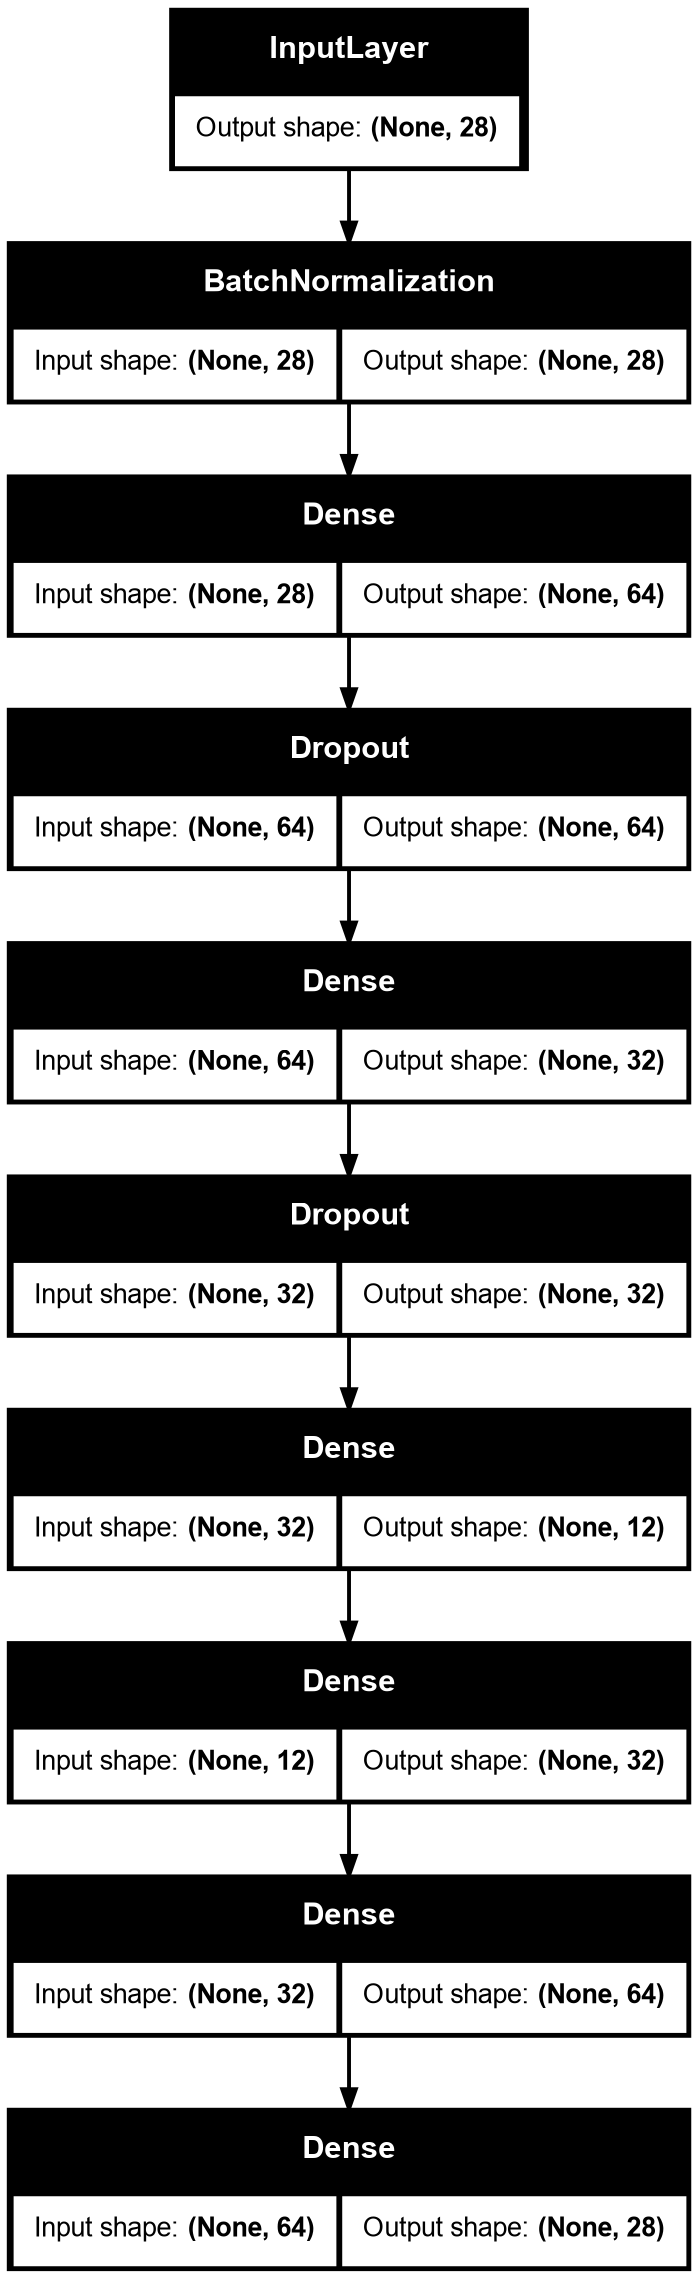

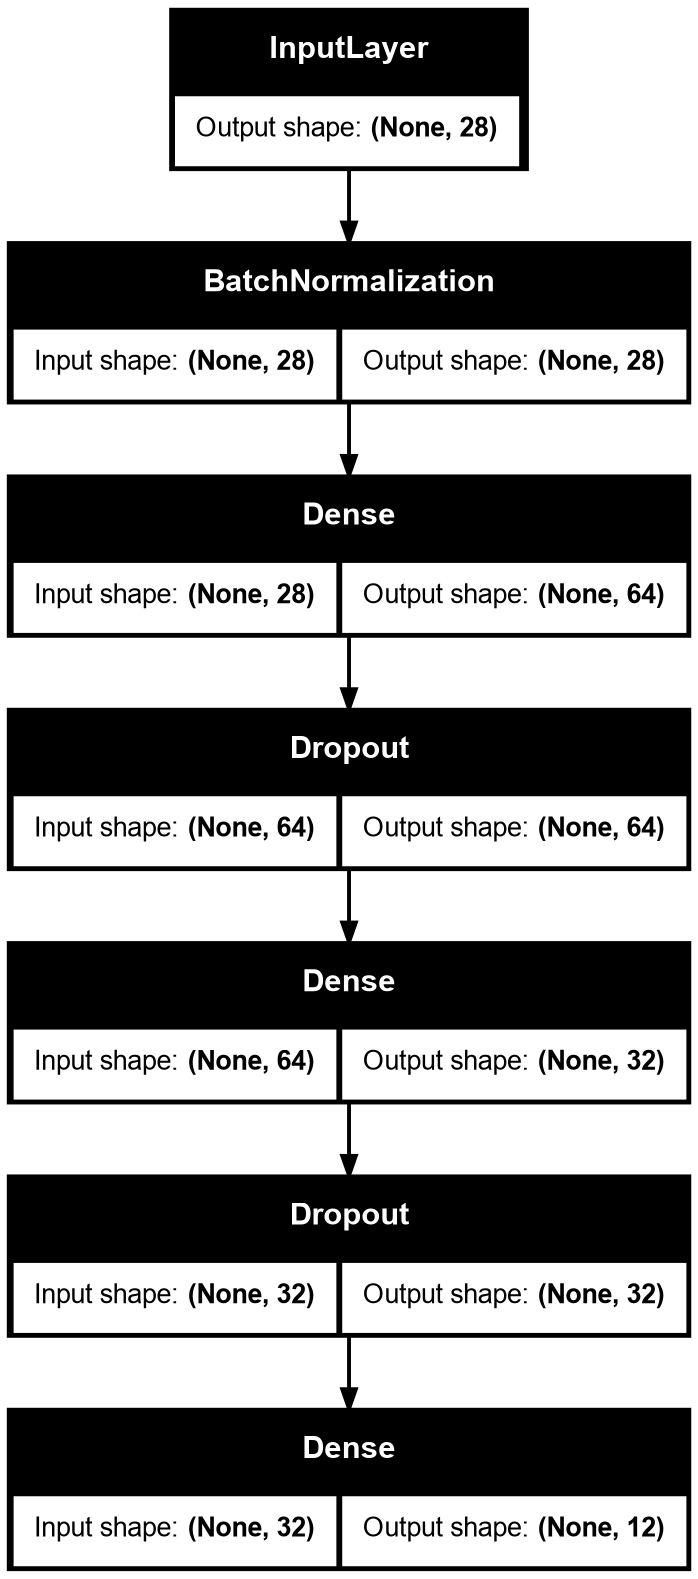

In [36]:
# --- summaries ---
ae.summary()
encoder.summary()

# --- architecture images (requires pydot + graphviz installed) ---
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display

plot_model(ae, to_file="autoencoder.png", show_shapes=True, expand_nested=True, dpi=140)
plot_model(encoder, to_file="encoder.png", show_shapes=True, expand_nested=True, dpi=140)

display(Image("autoencoder.png"))
display(Image("encoder.png"))


AE-only | Test accuracy: 0.34946236559139787
              precision    recall  f1-score   support

           0       0.18      0.20      0.19        25
           1       0.33      0.29      0.31        24
           2       0.52      0.46      0.49        28
           3       0.30      0.34      0.32        29
           4       0.38      0.26      0.31        23
           5       0.29      0.36      0.32        28
           6       0.48      0.48      0.48        29

    accuracy                           0.35       186
   macro avg       0.36      0.34      0.35       186
weighted avg       0.36      0.35      0.35       186



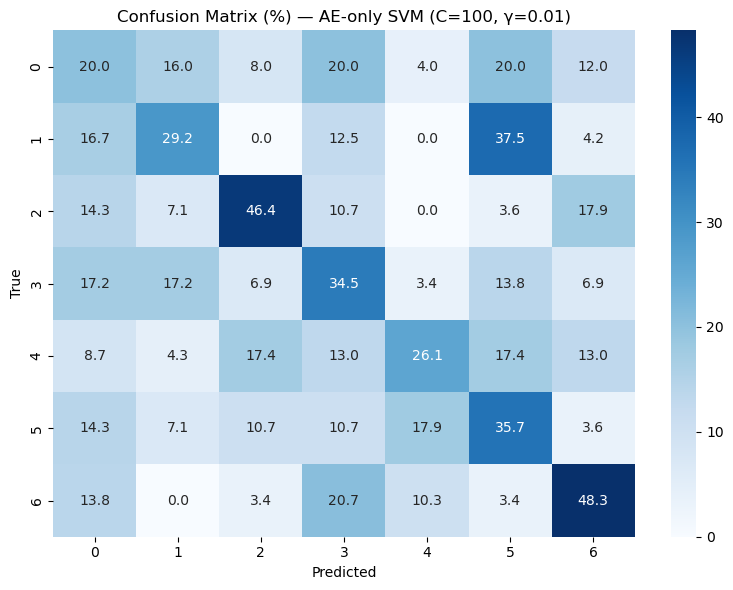

In [ ]:
# === AE-only features → scale → SVM (RBF, C=10, γ=0.1) ===
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Build AE feature frames from Z_train/Z_test
ae_cols = [f"ae_{i+1}" for i in range(Z_train.shape[1])]
X_train_ae = pd.DataFrame(Z_train, index=X_train.index, columns=ae_cols)
X_test_ae  = pd.DataFrame(Z_test,  index=X_test.index,  columns=ae_cols)

# (optional) export raw AE features
# X_train_ae.assign(label=y_train).to_csv("train_ae_features.csv", index=False)
# X_test_ae.assign(label=y_test).to_csv("test_ae_features.csv", index=False)

# 2) Scale AE features (fit on train only)
sc = StandardScaler()
Xtr = sc.fit_transform(X_train_ae)
Xte = sc.transform(X_test_ae)

# 3) Train SVM (your selected params)
svm = SVC(kernel="rbf", C=10, gamma=0.1, probability=True, random_state=42)
svm.fit(Xtr, y_train)
yp = svm.predict(Xte)

print("AE-only | Test accuracy:", accuracy_score(y_test, yp))
print(classification_report(y_test, yp))

# 4) Confusion matrix (%)
cm = confusion_matrix(y_test, yp, labels=np.unique(y_train))
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(8,6))
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix (%) — AE-only SVM (C=100, γ=0.01)")
plt.tight_layout(); plt.show()


Test accuracy: 0.532258064516129

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.20      0.30        25
           1       0.86      0.50      0.63        24
           2       0.37      0.64      0.47        28
           3       0.49      0.72      0.58        29
           4       0.78      0.30      0.44        23
           5       0.48      0.50      0.49        28
           6       0.65      0.76      0.70        29

    accuracy                           0.53       186
   macro avg       0.61      0.52      0.52       186
weighted avg       0.60      0.53      0.52       186



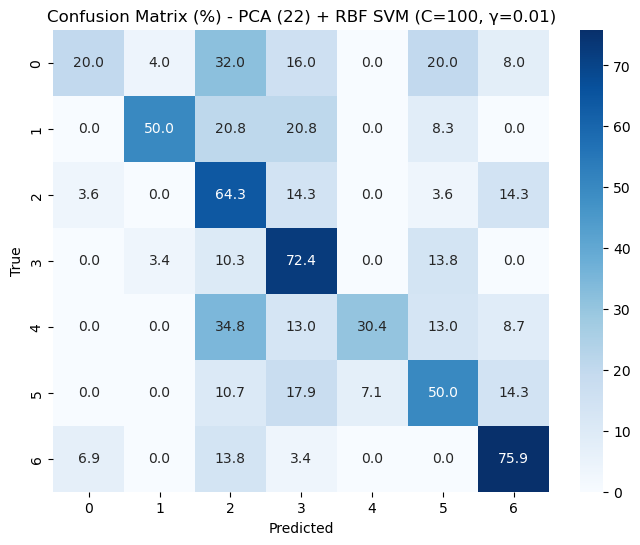

In [40]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- PCA (22 components) ---
pca = PCA(n_components=28, random_state=42)
X_train_pca = pca.fit_transform(X_train_top50)   # use top 50 features before PCA
X_test_pca = pca.transform(X_test_top50)

# --- Retrain with optimized RBF SVM ---
best_svm = SVC(
    kernel="rbf",
    C=10,
    gamma=0.1,
    probability=True,
    random_state=42
)
best_svm.fit(X_train_pca, y_train)

# --- Evaluate on test set ---
y_pred = best_svm.predict(X_test_pca)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --- Confusion matrix (percent) ---
cm = confusion_matrix(y_test, y_pred, labels=np.unique(y))
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(8,6))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (%) - PCA (22) + RBF SVM (C=100, γ=0.01)")
plt.show()


# Prediction

In [42]:
# --- 0) Load and engineer (NO FITTING ANYTHING NEW) ---
df_new = pd.read_csv("MJMusicDataset_Test.csv")
df_new = generate_extra_features(df_new)

# Safe drop if present
drop_cols = [c for c in ["name", "instrument", "dastgah"] if c in df_new.columns]
X_new = df_new.drop(columns=drop_cols)

# Align to training feature order used to fit the scaler
try:
    feature_cols = list(scaler.feature_names_in_)  # preferred (sklearn >=1.0)
except AttributeError:
    feature_cols = list(X.columns)                 # fallback if X from training is still in scope

X_new = X_new.reindex(columns=feature_cols, fill_value=0)

# Optional: true labels if present (for accuracy calc)
y_new = le.transform(df_new["dastgah"]) if "dastgah" in df_new.columns else None

# --- 1) Transform with existing scaler ---
X_new_scaled = scaler.transform(X_new)

# --- 2) Select the SAME top-50 features (indices from your trained LGBM) ---
X_new_top50 = X_new_scaled[:, sorted_idx]

# --- 3) PCA+SVM path (USING EXISTING FITTED PCA & SVM) ---
X_new_pca = pca.transform(X_new_top50)
y_pred_pca = svm_pca.predict(X_new_pca)

print("PCA+SVM predictions (first 20):", y_pred_pca[:20])
if y_new is not None:
    print("PCA+SVM accuracy on new file:", accuracy_score(y_new, y_pred_pca))

# --- 4) AE-only path (USING EXISTING FITTED ENCODER + AE SCALER + SVM) ---
Z_new = encoder.predict(X_new_pca)
Z_new_s = sc_ae.transform(Z_new)
y_pred_ae = svm_ae.predict(Z_new_s)

print("AE-only SVM predictions (first 20):", y_pred_ae[:20])
if y_new is not None:
    print("AE-only SVM accuracy on new file:", accuracy_score(y_new, y_pred_ae))


NameError: name 'svm_pca' is not defined